In [2]:
import pypsa
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [73]:
regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

regions_plot = regions.copy()
regions_plot['geometry'] = regions_plot['geometry'].to_crs(epsg=4258).simplify(tolerance=0.12)

In [21]:
gasuse = 1000
n = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / f'base_s_50__3H-T-H-B-I-A-dist1_2035_free_{gasuse}.nc')

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_1000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [74]:
n.statistics.withdrawal(groupby=['bus_carrier', 'bus'], aggregate_time=False)

snapshot                                                     2024-01-01 00:00:00  \
component   bus_carrier          bus                                               
StorageUnit AC                   AL0 0                                       NaN   
                                 AT0 0                                   0.00116   
                                 BA0 0                                       NaN   
                                 BE0 0                                       NaN   
                                 BG0 0                                       NaN   
...                                                                          ...   
Link        urban decentral heat RS0 0 urban decentral heat                  NaN   
                                 SE1 0 urban decentral heat                  NaN   
                                 SI0 0 urban decentral heat                  NaN   
                                 SK0 0 urban decentral heat                  NaN   
                                 XK0 0 urban decentral heat                  NaN   

snapshot                                                     2024-01-01 03:00:00  \
component   bus_carrier          bus                                               
StorageUnit AC                   AL0 0                                       NaN   
                                 AT0 0                                   0.00122   
                                 BA0 0                                       NaN   
                                 BE0 0                                 212.67448   
                                 BG0 0                                       NaN   
...                                                                          ...   
Link        urban decentral heat RS0 0 urban decentral heat                  NaN   
                                 SE1 0 urban decentral heat                  NaN   
                                 SI0 0 urban decentral heat                  NaN   
                                 SK0 0 urban decentral heat                  NaN   
                                 XK0 0 urban decentral heat                  NaN   

snapshot                                                     2024-01-01 06:00:00  \
component   bus_carrier          bus                                               
StorageUnit AC                   AL0 0                                       NaN   
                                 AT0 0                                   0.00108   
                                 BA0 0                                       NaN   
                                 BE0 0                                       NaN   
                                 BG0 0                                       NaN   
...                                                                          ...   
Link        urban decentral heat RS0 0 urban decentral heat                  NaN   
                                 SE1 0 urban decentral heat                  NaN   
                                 SI0 0 urban decentral heat                  NaN   
                                 SK0 0 urban decentral heat                  NaN   
                                 XK0 0 urban decentral heat                  NaN   

snapshot                                                     2024-01-01 09:00:00  \
component   bus_carrier          bus                                               
StorageUnit AC                   AL0 0                                       NaN   
                                 AT0 0                                5303.29793   
                                 BA0 0                                   0.00038   
                                 BE0 0                                 210.42710   
                                 BG0 0                                       NaN   
...                                                                          ...   
Link        urban decentral heat RS0 0 urban dece

In [75]:
def get_buses(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[:2].str.join(' ')

In [76]:
withdrawal = n.statistics.withdrawal(groupby=['bus_carrier', 'bus'], aggregate_time=False)

In [77]:
withdrawal.index.unique(1)

Index(['AC', 'biogas', 'co2', 'coal', 'gas', 'low voltage', 'oil primary',
       'rural heat', 'solid biomass', 'unsustainable bioliquids',
       'urban central heat', 'urban decentral heat', 'EV battery',
       'Hydrogen Storage', 'NH3', 'agriculture machinery oil',
       'coal for industry', 'gas for industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat<100 industry', 'heat>500 industry',
       'industry methanol', 'kerosene for aviation', 'land transport oil',
       'naphtha for industry', 'process emissions', 'shipping methanol',
       'shipping oil', 'solid biomass for industry', 'steel',
       'Battery Storage', 'co2 sequestered', 'co2 stored', 'home battery',
       'methanol', 'non-sequestered HVC', 'oil', 'hbi', 'steel emission'],
      dtype='object', name='bus_carrier')

In [78]:
carriers = [
    'AC',
    'rural heat',
    'urban decentral heat',
    'urban central heat',
    'H2',
    'heat100-200 industry',
    'heat200-500 industry',
    'heat>500 industry',
]
stats_names = {
    'H2': 'Hydrogen Storage'
}

weighted_bus_prices = {}

for carrier in carriers:
    buses = n.buses[n.buses.carrier == carrier].index
    carrier_stats = stats_names.get(carrier, carrier)
    
    marginal_prices = n.buses_t.marginal_price[buses]
    
    weights = withdrawal.loc[(slice(None), carrier_stats, buses), :]
    
    weights_by_bus = weights.groupby(level='bus').sum()
    weighted_prices = (marginal_prices * weights_by_bus.T).sum(axis=0) / weights_by_bus.sum(axis=1)
    weighted_prices.index = get_buses(weighted_prices.index)
    
    weighted_bus_prices[carrier] = weighted_prices

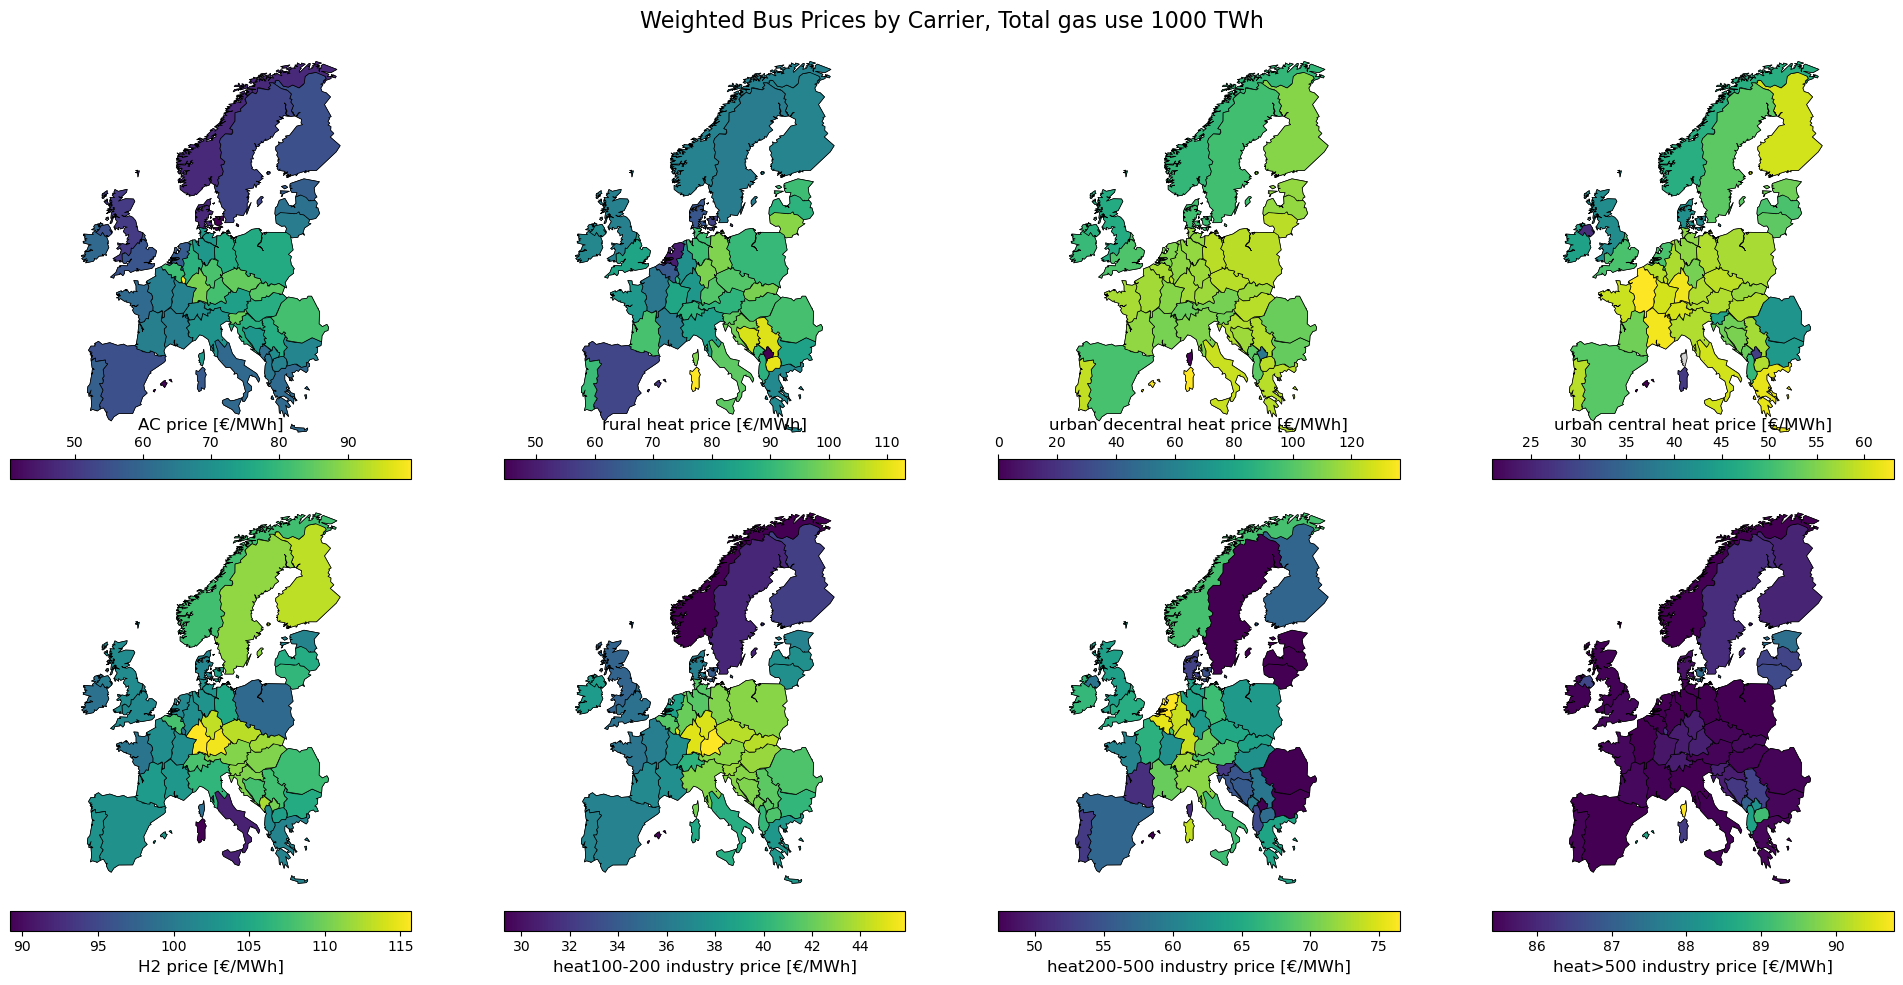

In [79]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, carrier in enumerate(carriers):
    ax = axes[idx]
    
    # Plot the map
    regions_plot.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
    
    # Get the weighted prices for this carrier
    prices = weighted_bus_prices[carrier]
    
    # Merge with regions_plot
    regions_with_prices = regions_plot.copy()
    regions_with_prices['price'] = regions_with_prices.index.map(prices)

    # Plot the prices
    regions_with_prices.plot(
        column='price',
        ax=ax,
        legend=False,
        edgecolor='black',
        linewidth=0.5,
        cmap='viridis',
        missing_kwds={'color': 'lightgray'}
    )
    
    # Remove spines
    ax.set_axis_off()
    
    # Add colorbar
    vmin = regions_with_prices['price'].min()
    vmax = regions_with_prices['price'].max()
    
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])
    
    # Position colorbar above for top row, below for bottom row
    if idx < 4:  # Top row
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
    else:  # Bottom row
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)
    
    cbar.set_label(carrier + ' price [€/MWh]', fontsize=12)

# Add title over the center of the plot
fig.suptitle(f'Weighted Bus Prices by Carrier, Total gas use {gasuse:.0f} TWh', fontsize=16, y=0.98)


plt.tight_layout()
plt.savefig(f'bus_energy_prices_{gasuse}.pdf', bbox_inches='tight')
plt.show()

In [80]:
eb = n.statistics.energy_balance(groupby=['bus_carrier', 'carrier', 'bus'])
eb.head()

component    bus_carrier  carrier               bus  
StorageUnit  AC           Pumped Hydro Storage  AT0 0   -4.400938e+06
                                                BA0 0   -2.918799e+03
                                                BE0 0   -2.899592e+05
                                                BG0 0   -6.417867e+05
                                                CH0 0   -4.084127e+06
dtype: float64

In [81]:
def get_buses(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[:2].str.join(' ')

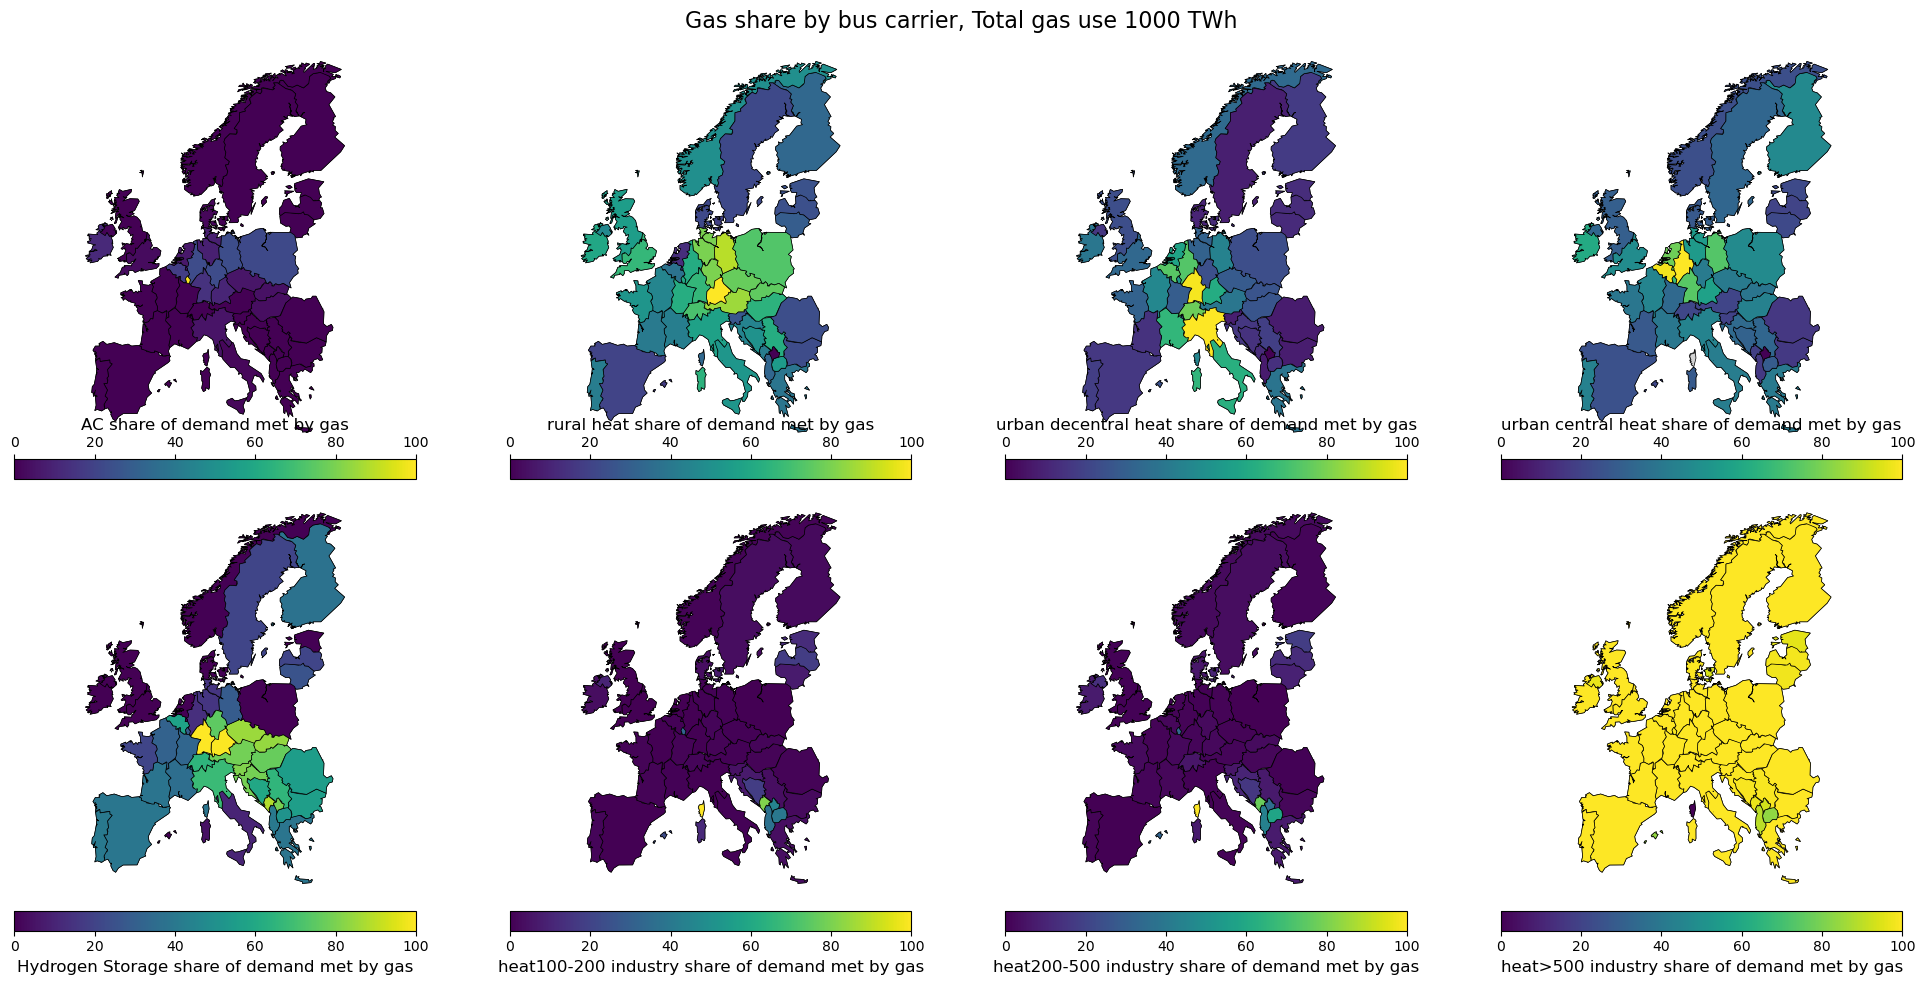

In [82]:
gas_techs_by_bus_carrier = {
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas", "urban central gas CHP"],
    "rural heat": ["rural gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "Hydrogen Storage": ["SMR"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "heat>500 industry": ["heat>500 industry gas"],
}
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (bc, techs) in enumerate(gas_techs_by_bus_carrier.items()):

    inflow = eb.loc[:, bc, :].clip(lower=0)
    totals = inflow.groupby(level=2).sum()
    gas_contribution = inflow.loc[:, techs, :].groupby(level=2).sum()

    totals.index = get_buses(totals.index)
    gas_contribution.index = get_buses(gas_contribution.index)

    gas_share = (gas_contribution / totals * 100).fillna(0)
    # print(gas_share)

    ax = axes[idx]
    
    # Plot the map
    regions_plot.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
    
    regions_with_share = regions_plot.copy()
    regions_with_share['share'] = regions_with_share.index.map(gas_share)
    
    # Plot the prices
    regions_with_share.plot(
        column='share',
        ax=ax,
        legend=False,
        edgecolor='black',
        linewidth=0.5,
        cmap='viridis',
        missing_kwds={'color': 'lightgray'}
    )
    
    # Remove spines
    ax.set_axis_off()
    
    # Add colorbar
    vmin = 0
    vmax = 100
    
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])
    
    # Position colorbar above for top row, below for bottom row
    if idx < 4:  # Top row
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
    else:  # Bottom row
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)
    
    cbar.set_label(bc + ' share of demand met by gas', fontsize=12)

# Add title over the center of the plot
fig.suptitle(f'Gas share by bus carrier, Total gas use {gasuse:.0f} TWh', fontsize=16, y=0.98)

plt.tight_layout()
plt.savefig(f'gas_share_by_bus_carrier_{gasuse}.pdf', bbox_inches='tight')
plt.show()